<a href="https://colab.research.google.com/github/Mubarok982/ComVis_UAS/blob/main/UAS_Comvis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Persiapan dan Download Dataset**

In [1]:
!pip install ultralytics roboflow opencv-python

from roboflow import Roboflow
# Load dataset dari Roboflow
rf = Roboflow(api_key="gN40pyeoC93cPiYsnvuP")
project = rf.workspace("roboflow-100").project("construction-safety-gsnvb")
version = project.version(2)
dataset = version.download("yolov8")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 99.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.7 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 5.0.0.93
    Uninstalling opencv-python-headless-5.0.0.93:
      Successfully uninstalled opencv-python-headless-5.0.0.93
  Attempting uninstall: typer
    Found existing installation: typer 0.26.8
    Uninstalling typer-0.26.8:
      Successfully uninstalled typer-0.26.8
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to construction-safety-2 in yolov8:: 100%|██████████| 2424/2424 [00:00<00:00, 3826.29it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


#**Preprocessing Citra (Memenuhi Kriteria 2)**
##**Karena gambar CCTV lu agak redup, kita pakai Color Conversion BGR ke LAB dan CLAHE untuk Noise Reduction/Contrast Enhancement**

In [2]:
import cv2
import os
import glob
from tqdm import tqdm

# KRITERIA 2: Preprocessing (Color conversion & Noise reduction/Enhancement)
def preprocess_images(image_folder):
    print(f"Melakukan preprocessing pada: {image_folder}")
    # Inisiasi CLAHE (Contrast Limited Adaptive Histogram Equalization)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    for img_path in tqdm(glob.glob(os.path.join(image_folder, '*.jpg'))):
        img = cv2.imread(img_path)
        if img is None: continue

        # Color Conversion (BGR ke LAB)
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)

        # Noise reduction & contrast enhancement pada channel kecerahan (L)
        l_clahe = clahe.apply(l)

        # Gabungkan dan kembalikan ke warna asli
        lab_merged = cv2.merge((l_clahe, a, b))
        img_enhanced = cv2.cvtColor(lab_merged, cv2.COLOR_LAB2BGR)

        # Timpa file asli dengan yang sudah di-preprocess
        cv2.imwrite(img_path, img_enhanced)

# Terapkan preprocessing ke dataset hasil download
preprocess_images(f"{dataset.location}/train/images")
preprocess_images(f"{dataset.location}/valid/images")

Melakukan preprocessing pada: /content/construction-safety-2/train/images


100%|██████████| 997/997 [00:46<00:00, 21.47it/s]


Melakukan preprocessing pada: /content/construction-safety-2/valid/images


100%|██████████| 119/119 [00:07<00:00, 16.89it/s]


#**Training Model YOLO (Memenuhi Kriteria 2 & 3)
(Sisa Kriteria 2 seperti Resize, Cropping, Normalisasi, dan Augmentasi gue masukin otomatis di fungsi bawaan YOLO biar optimal)**

In [3]:
from ultralytics import YOLO

# KRITERIA 3: Pengembangan Model Deep Learning (YOLOv8)
model = YOLO('yolov8s.pt')

print("Memulai proses training model...")
# KRITERIA 2 Lanjutan: Resize (imgsz), Data Augmentation (hsv, flip), Cropping (mosaic)
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=25,          # Ubah sesuai batas waktu lu di Colab
    imgsz=640,          # Kriteria: Resize & Normalisasi otomatis
    batch=16,
    hsv_h=0.015,        # Kriteria: Data Augmentation (Warna)
    hsv_s=0.7,
    hsv_v=0.4,
    fliplr=0.5,         # Kriteria: Data Augmentation (Horizontal Flip)
    mosaic=1.0,         # Kriteria: Data Augmentation (Cropping/Mosaic)
    project='/content/runs/detect',
    name='train'
)

Memulai proses training model...
Ultralytics 8.4.98 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/construction-safety-2/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, opt

#**Evaluasi Model (Memenuhi Kriteria 4)
(Script ini akan menghitung mAP, Precision, Recall, dan F1-Score sesuai permintaan dosen)**

In [4]:
# KRITERIA 4: Evaluasi Model
print("Melakukan evaluasi model...")
metrics = model.val()

# Ekstrak nilai dari hasil YOLO
precision = metrics.results_dict['metrics/precision(B)']
recall = metrics.results_dict['metrics/recall(B)']
map50 = metrics.results_dict['metrics/mAP50(B)'] # mAP adalah pengganti Accuracy di Object Detection

# Hitung F1-Score manual
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n" + "="*40)
print(f"📊 HASIL EVALUASI MODEL OBJECT DETECTION")
print(f"="*40)
print(f"✅ Precision          : {precision:.4f}")
print(f"✅ Recall             : {recall:.4f}")
print(f"✅ F1-Score           : {f1_score:.4f}")
print(f"✅ mAP@50 (Accuracy)  : {map50:.4f}")
print(f"="*40)

Melakukan evaluasi model...
Ultralytics 8.4.98 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2378.6±1055.9 MB/s, size: 2062.9 KB)
val: Scanning /content/construction-safety-2/valid/labels.cache... 119 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 119/119 49.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.8it/s 4.4s
                   all        119        715      0.905      0.856      0.909       0.49
                helmet        117        232      0.912      0.862      0.929      0.528
             no-helmet          6         11      0.887      0.909      0.897      0.351
               no-vest         52         90      0.893      0.689      0.847      0.434
                person        115        241      0.937      0.946      0.942      0.624
    

#**Tampilkan Visualisasi dan Download (Kode Asli Lu)
(Ini kode asli lu, tinggal jalanin paling terakhir buat nge-download hasilnya)**

GRAFIK HASIL TRAINING (RESULTS.PNG)


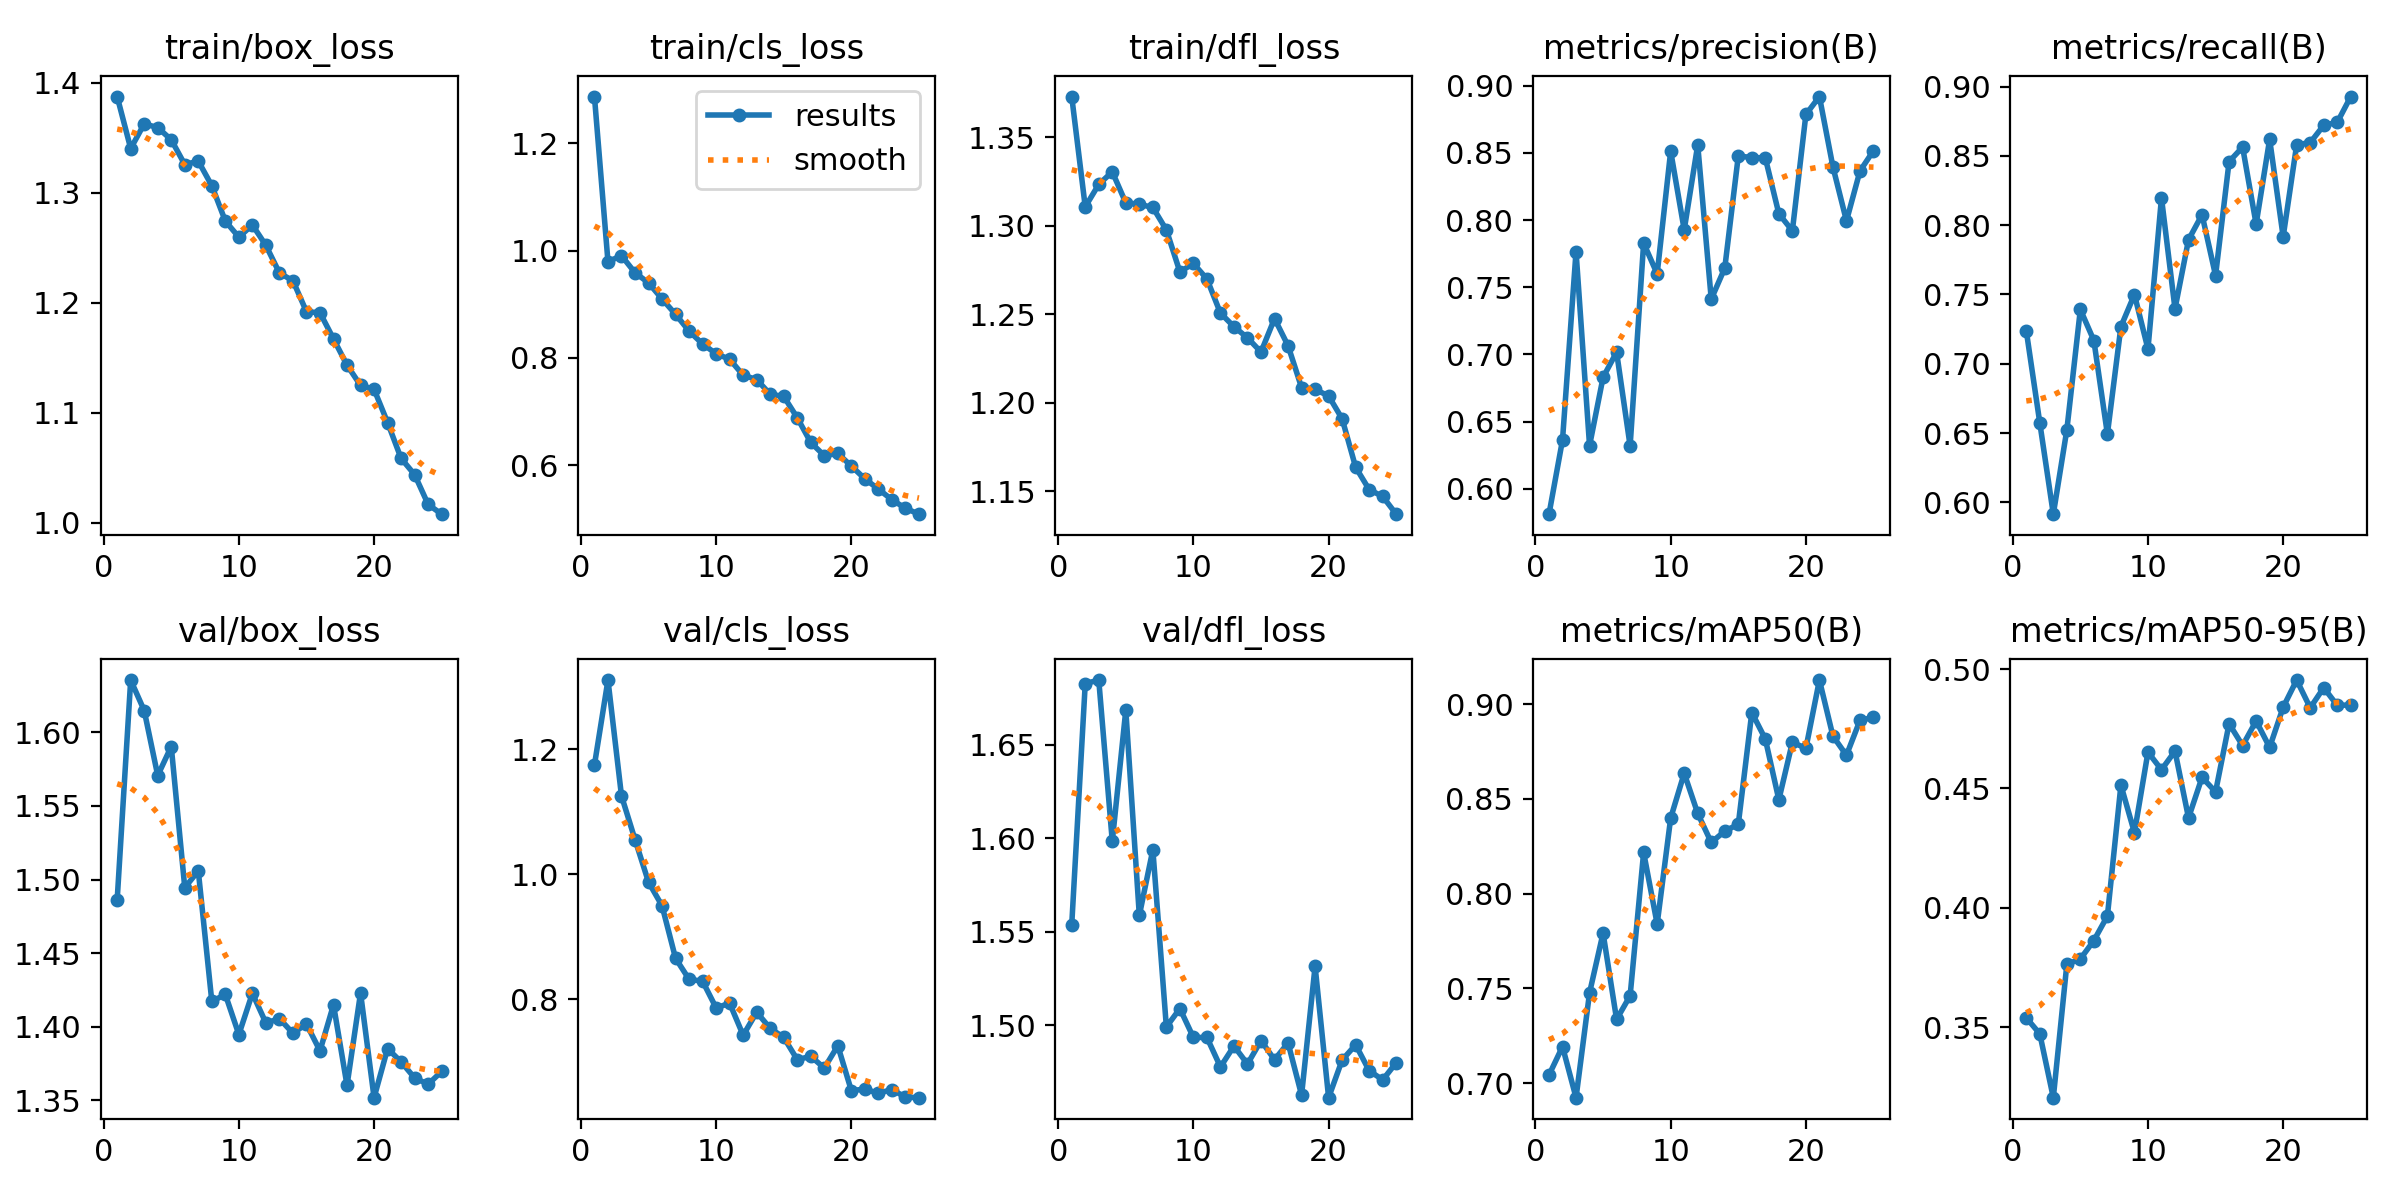

CONFUSION MATRIX


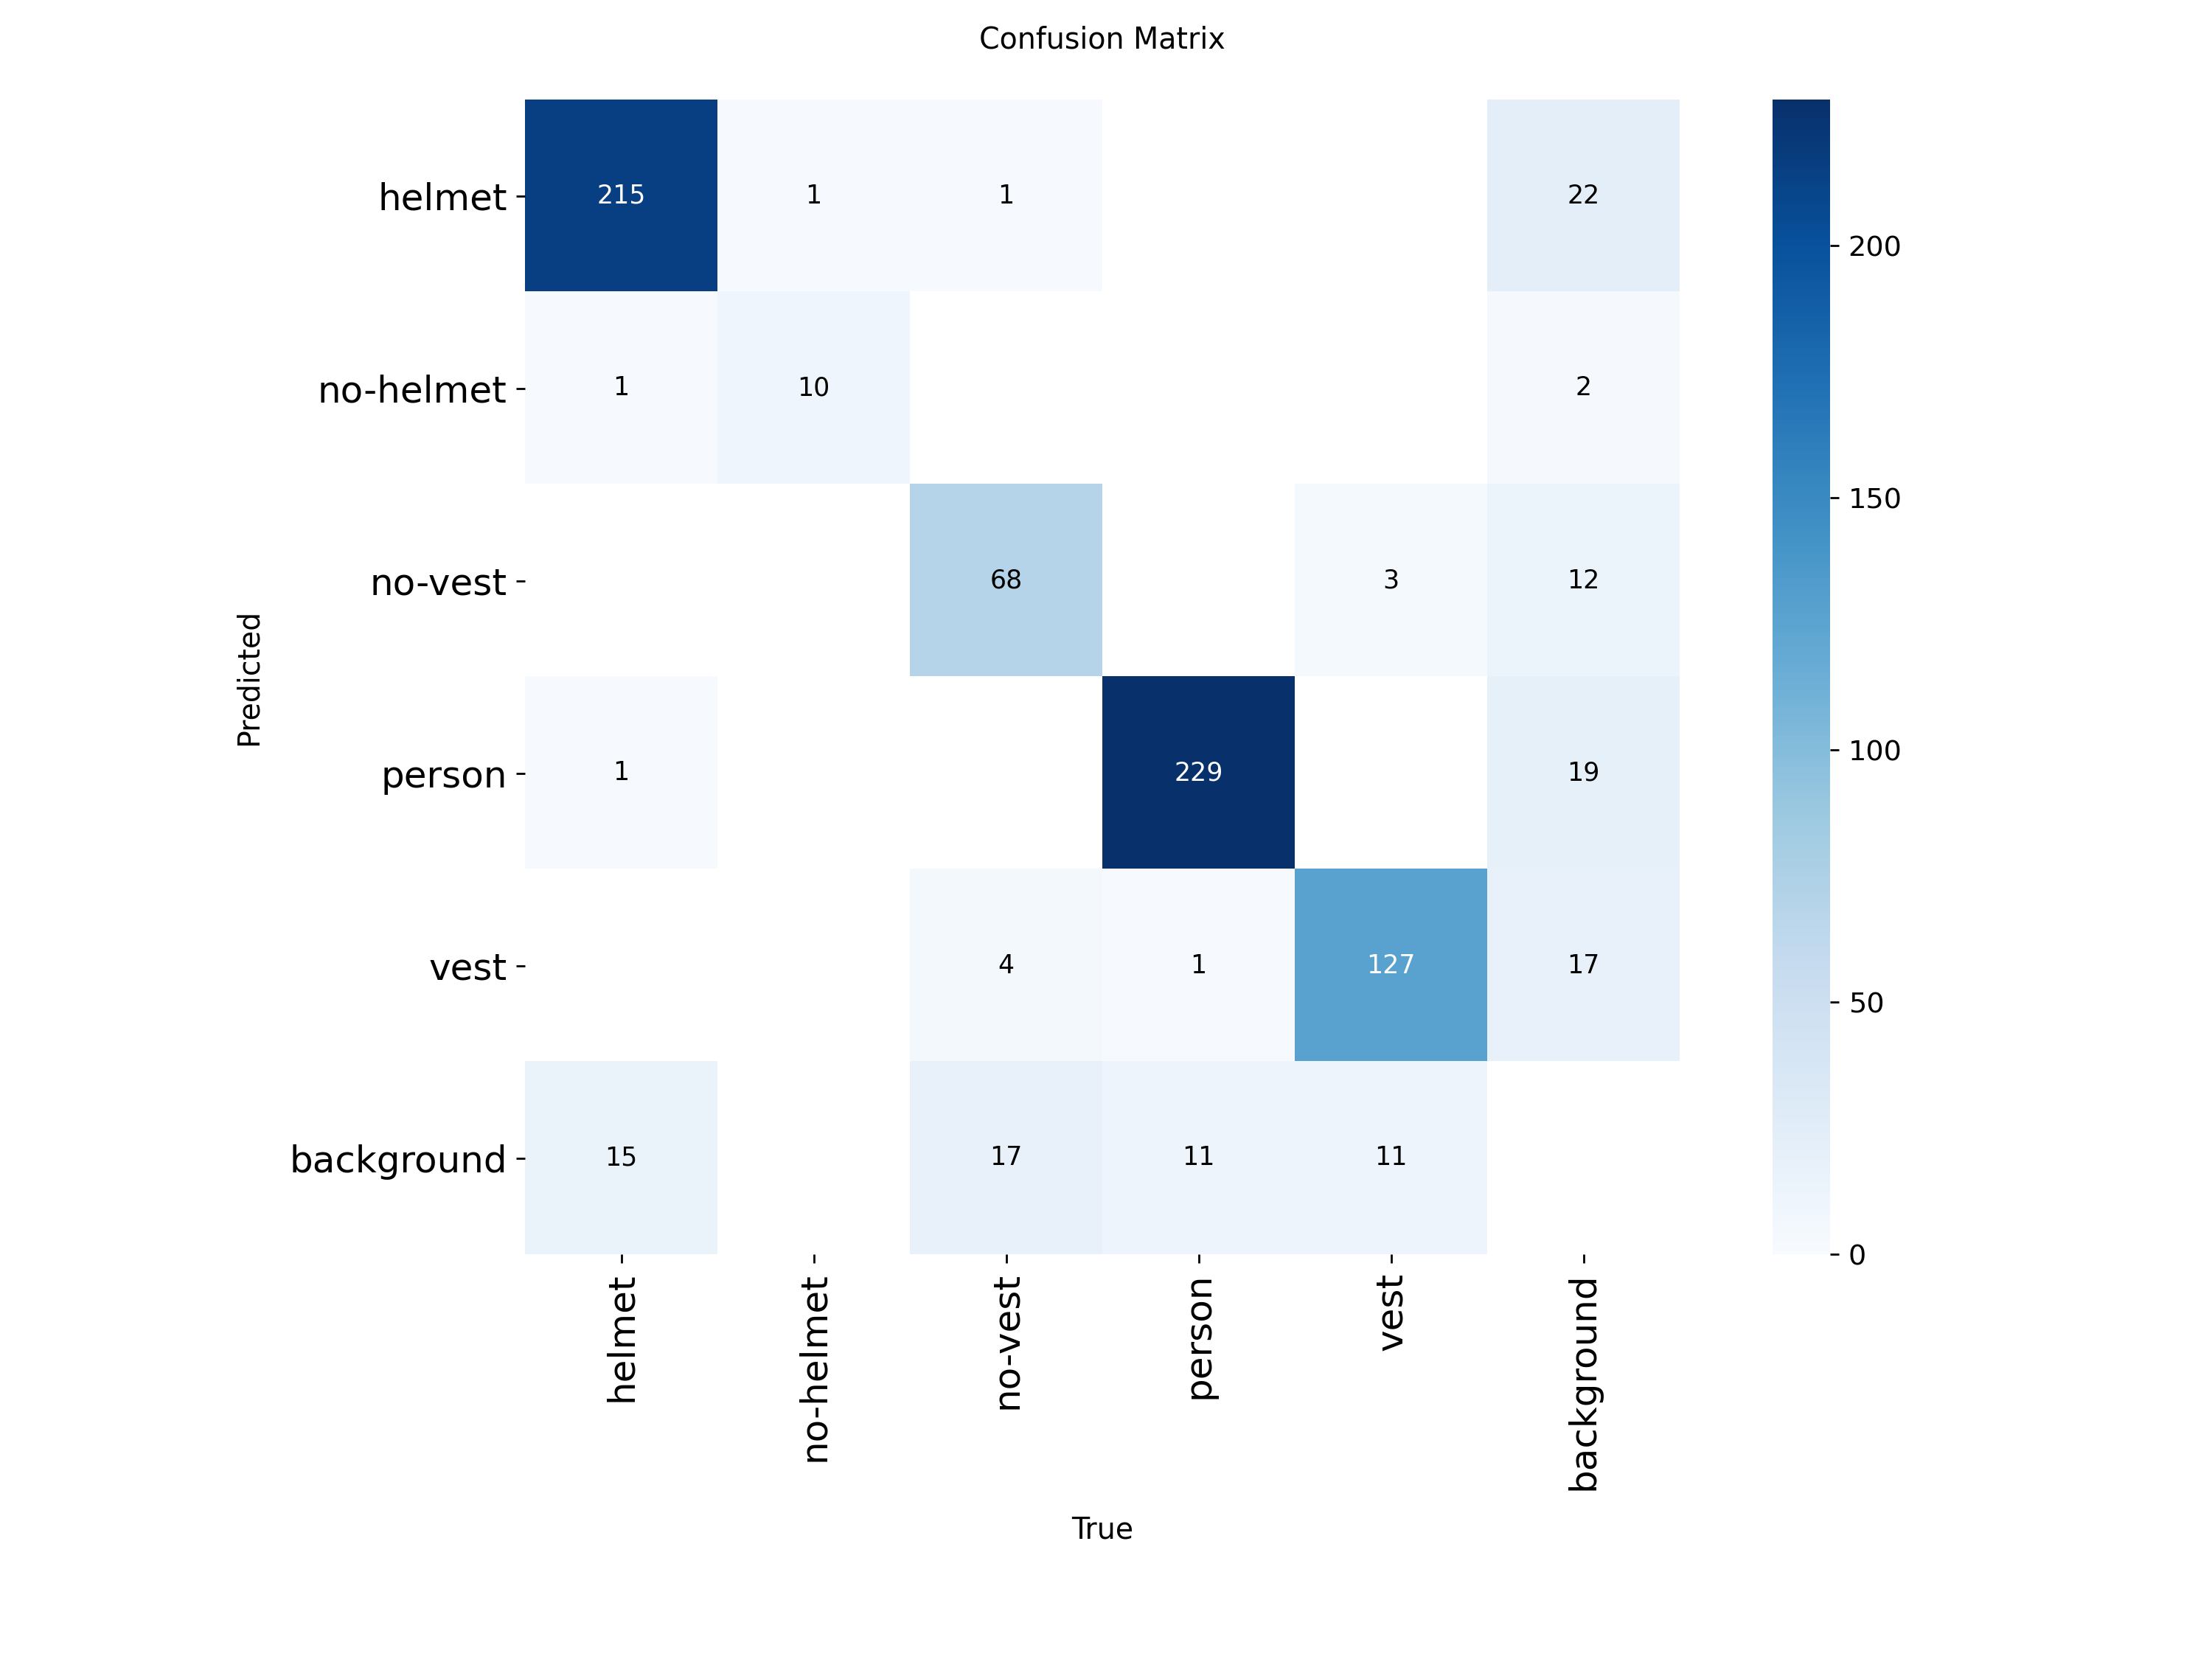

CONTOH HASIL DETEKSI PADA DATA VALIDASI


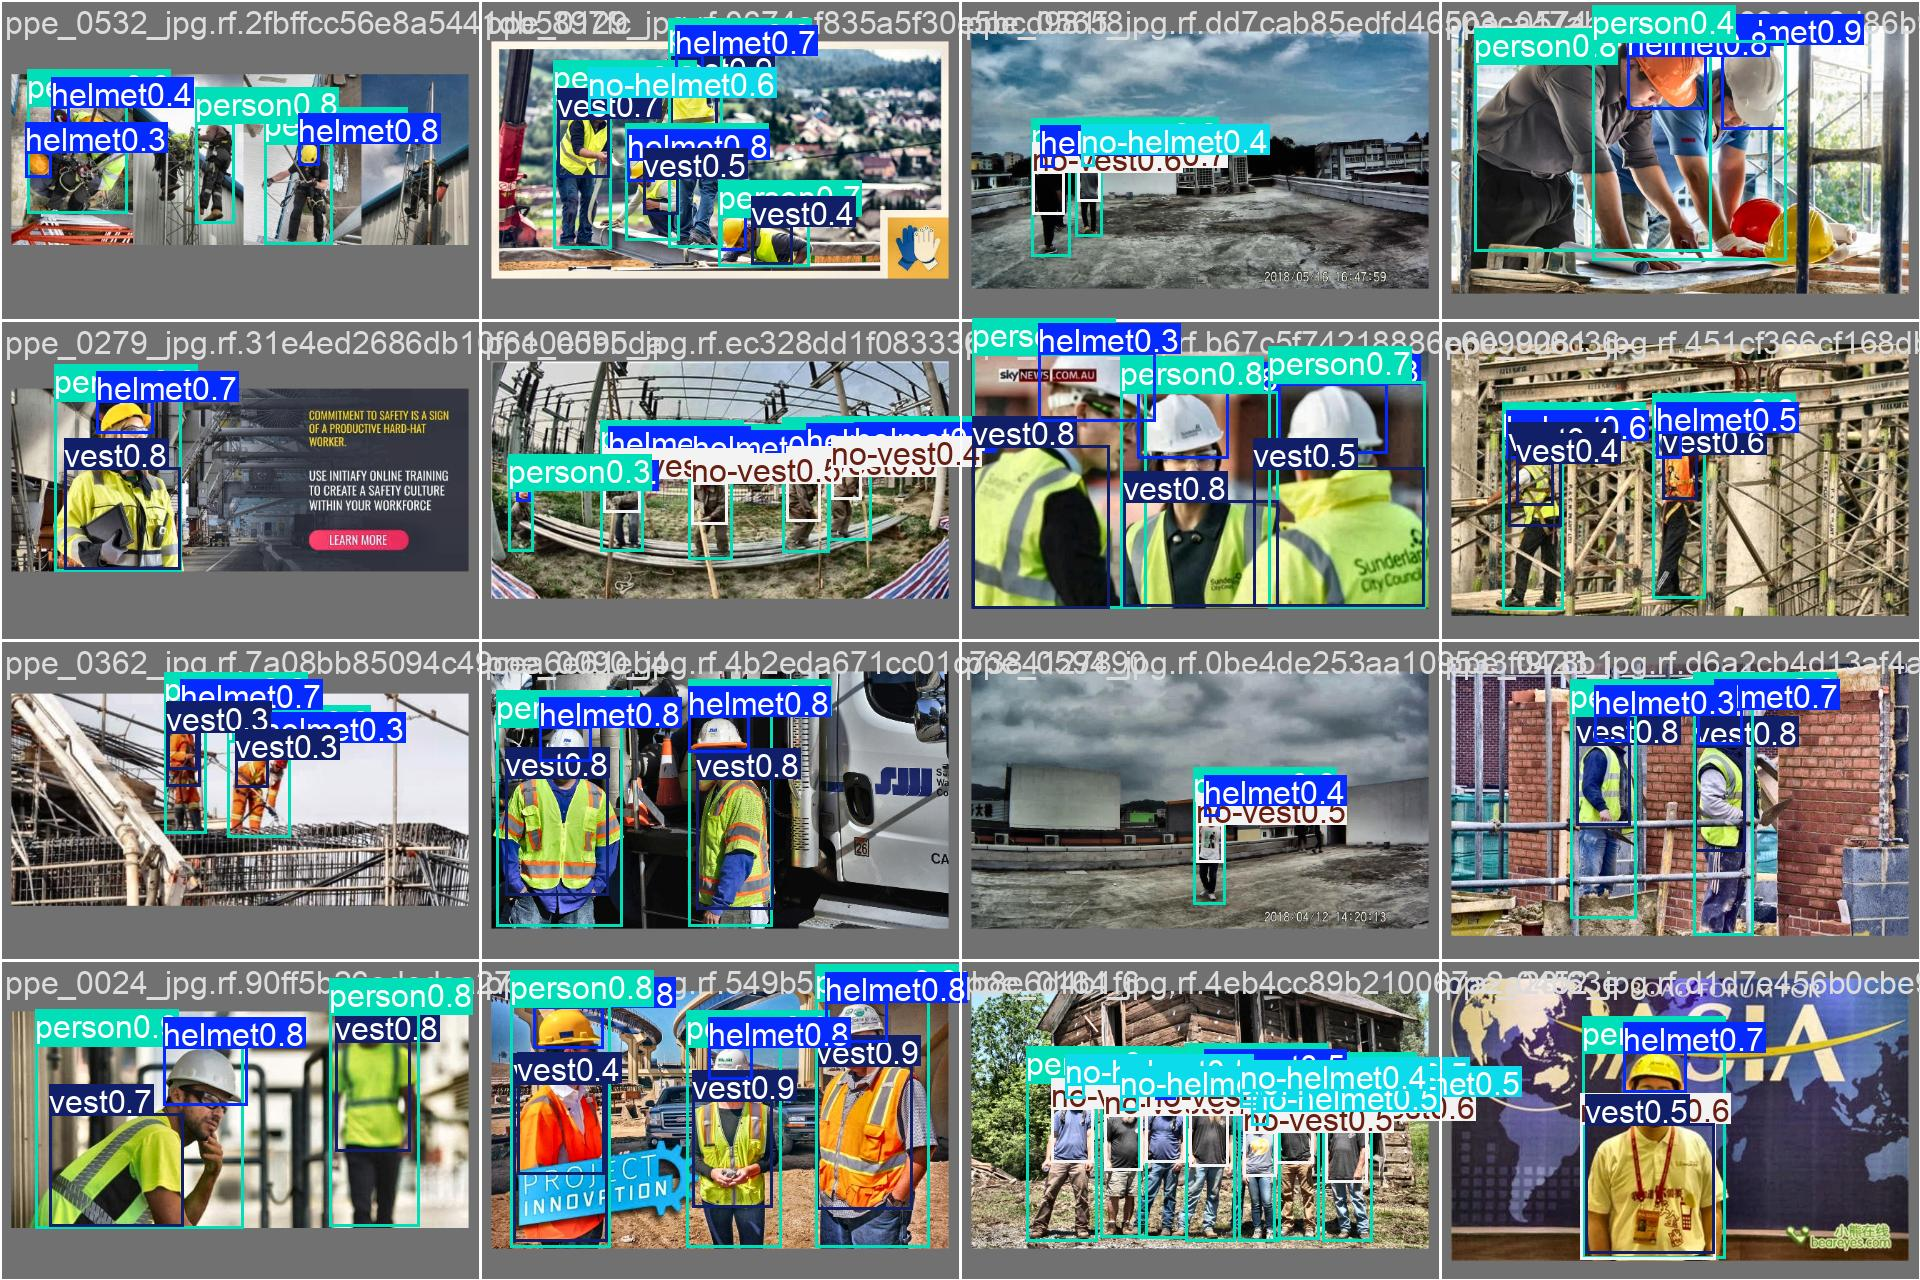

Sedang membungkus file hasil training...
Mendownload file hasil_training_uas.zip...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
from IPython.display import Image, display
import glob
import os
from google.colab import files

print("GRAFIK HASIL TRAINING (RESULTS.PNG)")
display(Image(filename='/content/runs/detect/train/results.png', width=1000))

print("CONFUSION MATRIX")
display(Image(filename='/content/runs/detect/train/confusion_matrix.png', width=800))

print("CONTOH HASIL DETEKSI PADA DATA VALIDASI")
for img in glob.glob('/content/runs/detect/train/val_batch0_pred.jpg')[:1]:
    display(Image(filename=img, width=1000))

print("Sedang membungkus file hasil training...")
os.system('zip -r /content/hasil_training_uas.zip /content/runs/detect/train')

print("Mendownload file hasil_training_uas.zip...")
files.download('/content/hasil_training_uas.zip')

CONTOH HASIL DETEKSI PADA DATA VALIDASI


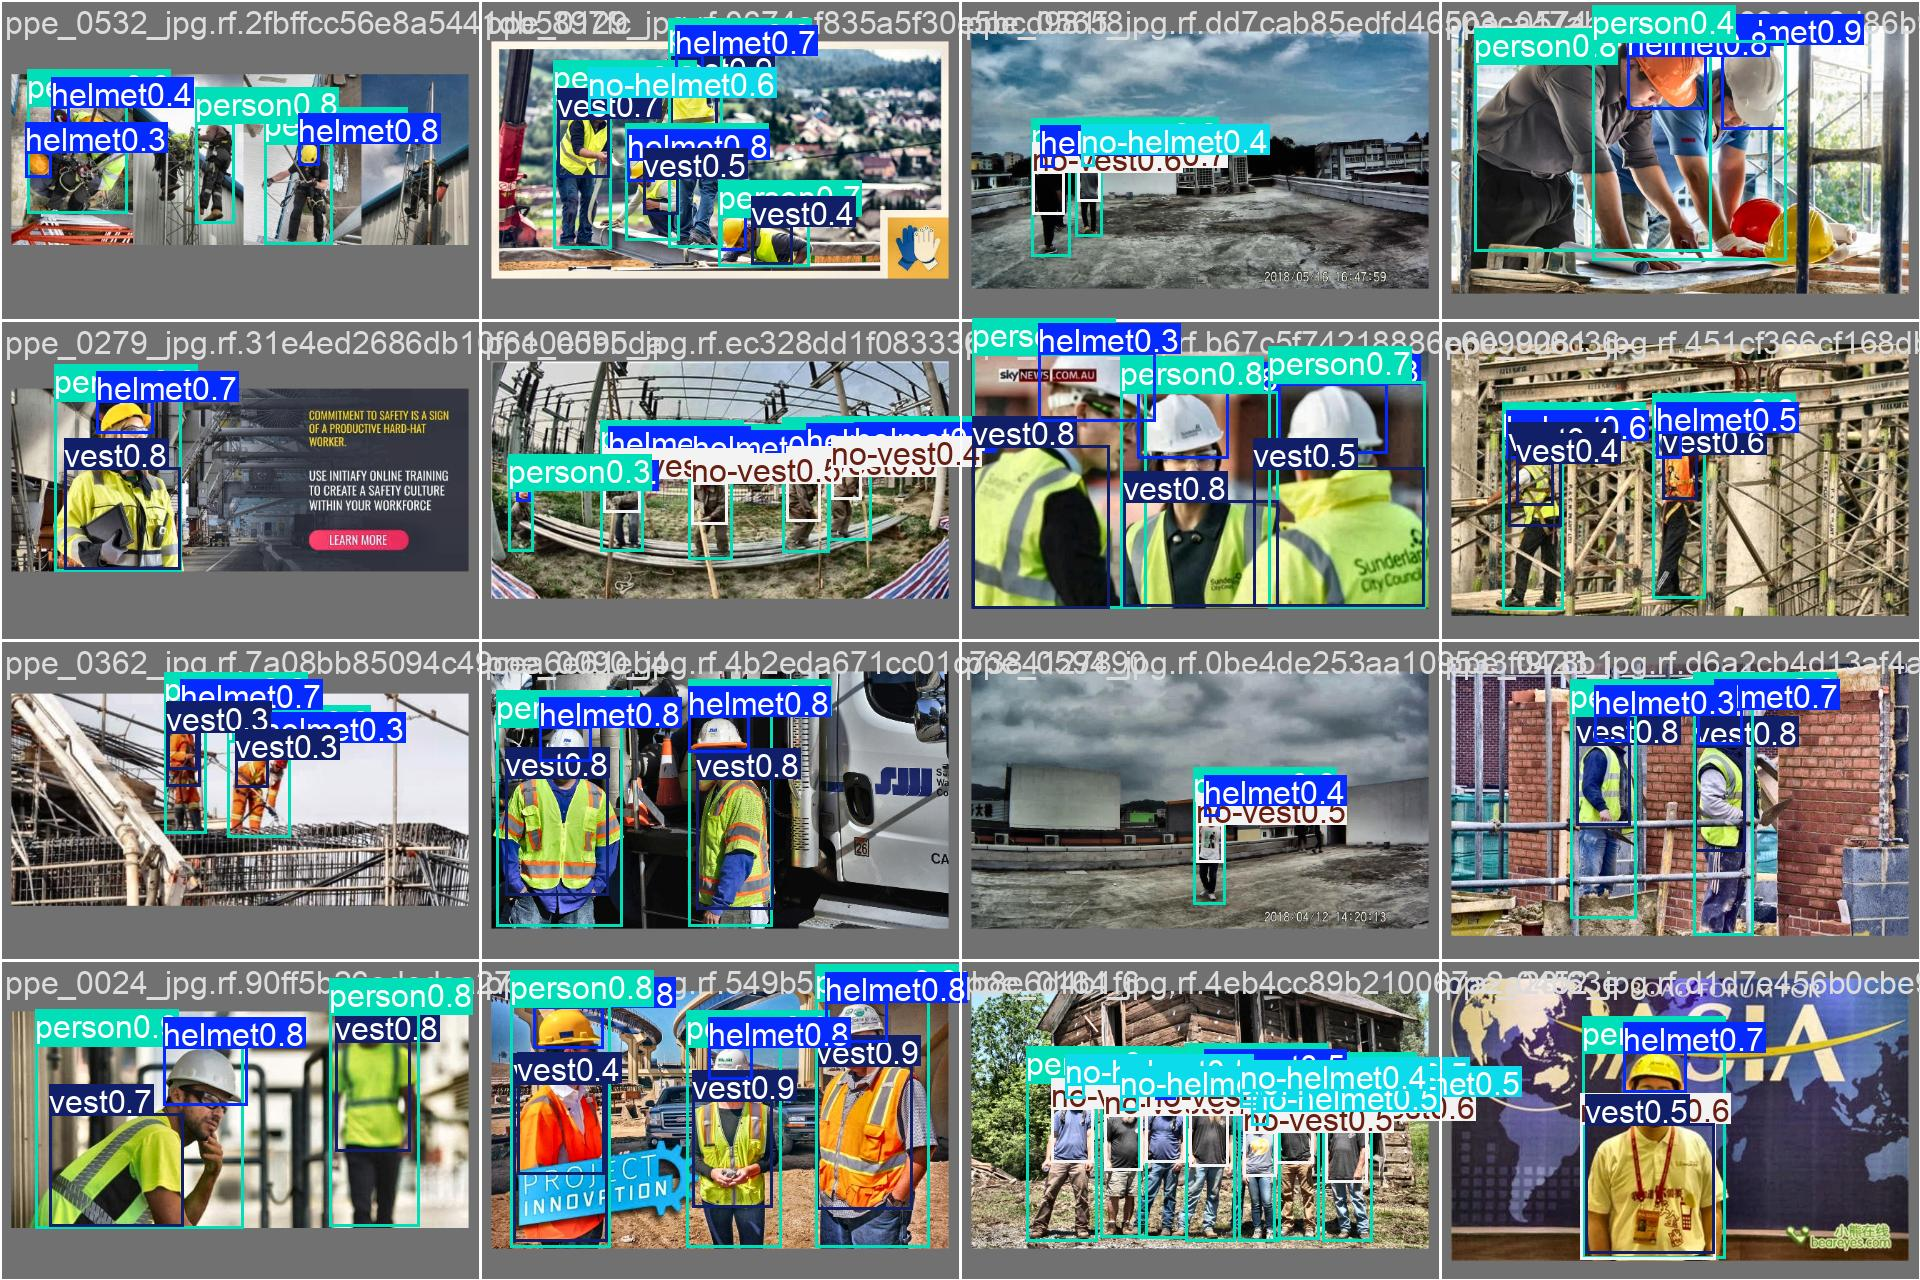

In [6]:
import glob

# Mengambil 3 gambar contoh tebakan dari model
print("CONTOH HASIL DETEKSI PADA DATA VALIDASI")
for img in glob.glob('/content/runs/detect/train/val_batch0_pred.jpg')[:1]:
    display(Image(filename=img, width=1000))

In [7]:
import os
from google.colab import files

# Membungkus seluruh folder hasil training jadi satu file .zip
print("Sedang membungkus file hasil training...")
os.system('zip -r /content/hasil_training_uas.zip /content/runs/detect/train')

# Mendownload file zip ke laptop
print("Mendownload file hasil_training_uas.zip...")
files.download('/content/hasil_training_uas.zip')

Sedang membungkus file hasil training...
Mendownload file hasil_training_uas.zip...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>